# 03-linear-reg-demographic-health-data

**1. CARGA DEL DATASET**

In [1]:
# IMPORTO LAS LIBRERÍAS NECESARIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2, SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

In [2]:
# CARGO LOS DATOS
url = "https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv"
total_data = pd.read_csv(url)
total_data

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,56037,43051,6104,14.178532,6326,14.694200,5359,12.448027,6577,15.277229,...,2098,8.9,8.3,9.6,2834,2.6,2.4,2.8,821,5
3136,56039,23081,2384,10.328842,2185,9.466661,2967,12.854729,4093,17.733200,...,928,7.2,6.5,8.0,1360,2.4,2.2,2.6,447,5
3137,56041,20299,3121,15.375142,3205,15.788955,2153,10.606434,2702,13.311001,...,1163,10.4,9.5,11.2,1500,3.0,2.8,3.2,430,5
3138,56043,7885,858,10.881420,1113,14.115409,715,9.067850,903,11.452124,...,506,11.3,10.3,12.1,686,3.4,3.2,3.7,207,6


In [3]:
total_data.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [4]:
total_data.tail()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
3135,56037,43051,6104,14.178532,6326,14.694200,5359,12.448027,6577,15.277229,...,2098,8.9,8.3,9.6,2834,2.6,2.4,2.8,821,5
3136,56039,23081,2384,10.328842,2185,9.466661,2967,12.854729,4093,17.733200,...,928,7.2,6.5,8.0,1360,2.4,2.2,2.6,447,5
3137,56041,20299,3121,15.375142,3205,15.788955,2153,10.606434,2702,13.311001,...,1163,10.4,9.5,11.2,1500,3.0,2.8,3.2,430,5
3138,56043,7885,858,10.881420,1113,14.115409,715,9.067850,903,11.452124,...,506,11.3,10.3,12.1,686,3.4,3.2,3.7,207,6
3139,56045,6967,780,11.195637,779,11.181283,681,9.774652,906,13.004162,...,480,11.7,10.7,12.7,644,3.4,3.1,3.6,185,6


In [5]:
total_data.shape

(3140, 108)

In [6]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), str(2)
memory usage: 2.6 MB


In [7]:
total_data.columns

Index(['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct',
       '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop',
       '30-39', '30-39 y/o % of total pop',
       ...
       'COPD_number', 'diabetes_prevalence', 'diabetes_Lower 95% CI',
       'diabetes_Upper 95% CI', 'diabetes_number', 'CKD_prevalence',
       'CKD_Lower 95% CI', 'CKD_Upper 95% CI', 'CKD_number',
       'Urban_rural_code'],
      dtype='str', length=108)

- El dataset contiene 3140 filas y 108 columnas relacionadas con datos sociodemográficos a nivel de condado de EE. UU. (2018-2019).
- Incluye variables relacionadas con la salud de las personas.
- El objetivo es descubrir si existe alguna relación entre los recursos de salud y los datos sociodemográficos.

In [8]:
# TODOS LOS VALORES FALTANTES DEL DATAFRAME
total_data.isna().sum().sum()

np.int64(0)

In [9]:
# CUENTO LOS VALORES NULOS PARA CADA COLUMNA
total_data.isna().sum()

fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64

In [10]:
(total_data.isna().sum() / len(total_data) * 100).sort_values(ascending=False)

fips                      0.0
TOT_POP                   0.0
0-9                       0.0
0-9 y/o % of total pop    0.0
19-Oct                    0.0
                         ... 
CKD_prevalence            0.0
CKD_Lower 95% CI          0.0
CKD_Upper 95% CI          0.0
CKD_number                0.0
Urban_rural_code          0.0
Length: 108, dtype: float64

In [11]:
total_data.isnull().sum()

fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64

In [12]:
# POSIBLES DATOS CATEGÓRICOS
total_data.select_dtypes(include=['object']).columns

/tmp/ipykernel_15410/1623080498.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  total_data.select_dtypes(include=['object']).columns


Index(['COUNTY_NAME', 'STATE_NAME'], dtype='str')

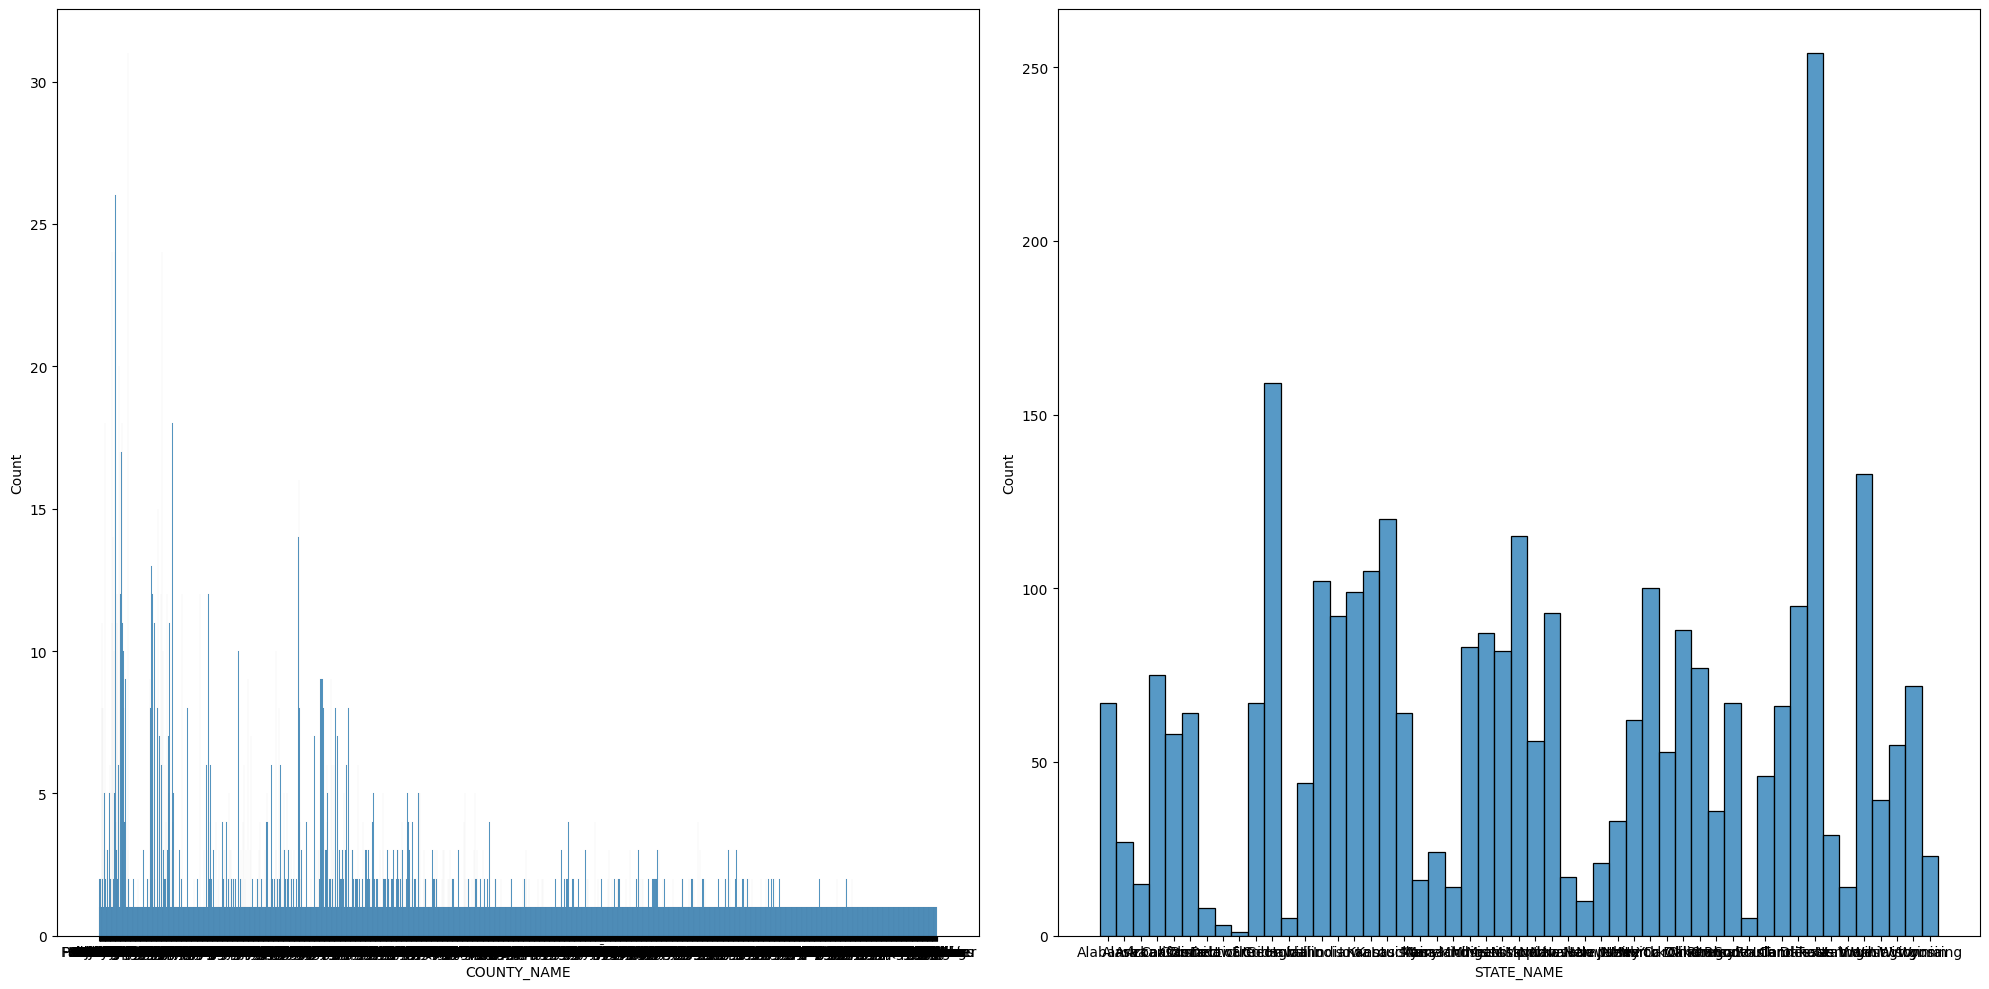

In [13]:
# HISTOGRA MÚLTIPLE
fig, axis = plt.subplots(1, 2, figsize=(20, 10))

sns.histplot(data=total_data, x='COUNTY_NAME', ax=axis[0])
sns.histplot(data=total_data, x='STATE_NAME', ax=axis[1])

plt.tight_layout()
plt.show()

**2. LIMPIEZA INICIAL**

In [14]:
total_data.duplicated().sum()

np.int64(0)

In [15]:
total_data[total_data.duplicated() == True]

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code


In [16]:
total_data.value_counts()

fips   TOT_POP  0-9    0-9 y/o % of total pop  19-Oct  10-19 y/o % of total pop  20-29  20-29 y/o % of total pop  30-39  30-39 y/o % of total pop  40-49  40-49 y/o % of total pop  50-59  50-59 y/o % of total pop  60-69  60-69 y/o % of total pop  70-79  70-79 y/o % of total pop  80+   80+ y/o % of total pop  White-alone pop  % White-alone  Black-alone pop  % Black-alone  Native American/American Indian-alone pop  % NA/AI-alone  Asian-alone pop  % Asian-alone  Hawaiian/Pacific Islander-alone pop  % Hawaiian/PI-alone  Two or more races pop  % Two or more races  POP_ESTIMATE_2018  N_POP_CHG_2018  GQ_ESTIMATES_2018  R_birth_2018  R_death_2018  R_NATURAL_INC_2018  R_INTERNATIONAL_MIG_2018  R_DOMESTIC_MIG_2018  R_NET_MIG_2018  Less than a high school diploma 2014-18  High school diploma only 2014-18  Some college or associate's degree 2014-18  Bachelor's degree or higher 2014-18  Percent of adults with less than a high school diploma 2014-18  Percent of adults with a high school diploma only 

In [17]:
total_data = total_data.drop_duplicates(keep="first")
print(total_data.shape)
total_data.head()

(3140, 108)


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [18]:
# ELIMINO LAS VARIABLES CATEGÓRICAS
total_data.drop(columns=['COUNTY_NAME','STATE_NAME'], inplace=True)
total_data = total_data.dropna().reset_index(drop=True)
total_data.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


- Se eliminaron las variables 'COUNTY_NAME' y 'STATE_NAME' porque no aportan valor predictivo al modelo. Además, al ser las únicas variables categóricas, no se pueden utilizar directamente en una regresión lineal sin que se transformen previamente.

In [19]:
# OTRAS COLUMNAS QUE DECIDÍ ELIMINAR
total_data.drop(columns=['anycondition_Lower 95% CI','anycondition_Upper 95% CI', 'anycondition_number', 'fips', 'STATE_FIPS', 'CNTY_FIPS'], inplace=True)
total_data = total_data.dropna().reset_index(drop=True)
total_data.head()

,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,3038,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,7474,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [20]:
# ELIMINAR COLUMNAS REPETITIVAS SOBRE ENFERMEDADES
repetitive_cols = [
    # Obesidad
    'Obesity_prevalence', 'Obesity_Lower 95% CI', 'Obesity_Upper 95% CI', 'Obesity_number',
    # Enfermedades del corazón
    'Heart disease_prevalence', 'Heart disease_Lower 95% CI', 'Heart disease_Upper 95% CI', 'Heart disease_number',
    # COPD
    'COPD_prevalence', 'COPD_Lower 95% CI', 'COPD_Upper 95% CI', 'COPD_number',
    # Diabetes
    'diabetes_prevalence', 'diabetes_Lower 95% CI', 'diabetes_Upper 95% CI', 'diabetes_number',
    # Enfermedad renal
    'CKD_prevalence', 'CKD_Lower 95% CI', 'CKD_Upper 95% CI', 'CKD_number',
]

total_data = total_data.drop(columns=repetitive_cols)

In [21]:
total_data.shape

(3140, 80)

In [22]:
total_data.isna().sum()

TOT_POP                           0
0-9                               0
0-9 y/o % of total pop            0
19-Oct                            0
10-19 y/o % of total pop          0
                                 ..
Population Aged 60+               0
Percent of Population Aged 60+    0
county_pop2018_18 and older       0
anycondition_prevalence           0
Urban_rural_code                  0
Length: 80, dtype: int64

In [23]:
total_data.columns

Index(['TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct',
       '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop',
       '30-39', '30-39 y/o % of total pop', '40-49',
       '40-49 y/o % of total pop', '50-59', '50-59 y/o % of total pop',
       '60-69', '60-69 y/o % of total pop', '70-79',
       '70-79 y/o % of total pop', '80+', '80+ y/o % of total pop',
       'White-alone pop', '% White-alone', 'Black-alone pop', '% Black-alone',
       'Native American/American Indian-alone pop', '% NA/AI-alone',
       'Asian-alone pop', '% Asian-alone',
       'Hawaiian/Pacific Islander-alone pop', '% Hawaiian/PI-alone',
       'Two or more races pop', '% Two or more races', 'POP_ESTIMATE_2018',
       'N_POP_CHG_2018', 'GQ_ESTIMATES_2018', 'R_birth_2018', 'R_death_2018',
       'R_NATURAL_INC_2018', 'R_INTERNATIONAL_MIG_2018', 'R_DOMESTIC_MIG_2018',
       'R_NET_MIG_2018', 'Less than a high school diploma 2014-18',
       'High school diploma only 2014-18',
       'Some col

**3. ANÁLISIS DE VARIABLES**

- Se eliminaron las variables 'COUNTY_NAME' y 'STATE_NAME' porque no aportan valor predictivo al modelo. Además, al ser las únicas variables categóricas, no se pueden utilizar directamente en una regresión lineal sin transformarlas previamente.
- Se eliminaron las variables 'anycondition_Lower 95% CI','anycondition_Upper 95% CI' y 'anycondition_number' porque son derivados directos de la variable objetivo y dejarlas podría causar data leakage.
- Se eliminaron las variables 'fips', 'STATE_FIPS', 'CNTY_FIPS' porque son identificadores; no aportan valor.
- Debido al alto número de variables numéricas (100), se seleccionaron aquellas con mayor correlación con la variable objetivo para facilitar la interpretación.
- Se seleccionó 'anycondition_prevalence' como variable objetivo, ya que representa el porcentaje de población con alguna condición médica, siendo un indicador global del estado de salud. Esto permite analizar cómo los factores sociodemográficos y los recursos sanitarios influyen en la salud de la población.

In [24]:
target = 'anycondition_prevalence'

In [25]:
# Correlación con la variable objetivo
corr = total_data.corr()
corr_target = corr[target].sort_values(ascending=False)
corr_target

anycondition_prevalence                                         1.000000
PCTPOV017_2018                                                  0.694607
PCTPOV517_2018                                                  0.681035
Percent of adults with a high school diploma only 2014-18       0.619251
PCTPOVALL_2018                                                  0.617216
                                                                  ...   
CI90UBINC_2018                                                 -0.698453
Median_Household_Income_2018                                   -0.706113
MEDHHINC_2018                                                  -0.706113
CI90LBINC_2018                                                 -0.708710
Percent of adults with a bachelor's degree or higher 2014-18   -0.768119
Name: anycondition_prevalence, Length: 80, dtype: float64

In [26]:
top_features = [
    "Percent of adults with a bachelor's degree or higher 2014-18",
    "PCTPOVALL_2018",
    "MEDHHINC_2018",
    "Unemployment_rate_2018",
    "Percent of Population Aged 60+",
    "80+ y/o % of total pop",
    "Active Physicians per 100000 Population 2018 (AAMC)",
    "ICU Beds_x",
    "Total Hospitals (2019)",
    "Urban_rural_code"
]

- Económicas: 'PCTPOVALL_2018', 'MEDHHINC_2018', 'Unemployment_rate_2018'
- Educación: 'Percent of adults with a bachelor's degree or higher 2014-18'
- Demográficas: 'Percent of Population Aged 60+', '80+ y/o % of total pop'
- Recursos de salud: 'Active Physicians per 100000 Population 2018 (AAMC)', 'ICU Beds_x', 'Total Hospitals (2019)'
- Ruralidad: 'Urban_rural_code'

<Axes: xlabel='anycondition_prevalence', ylabel='Count'>

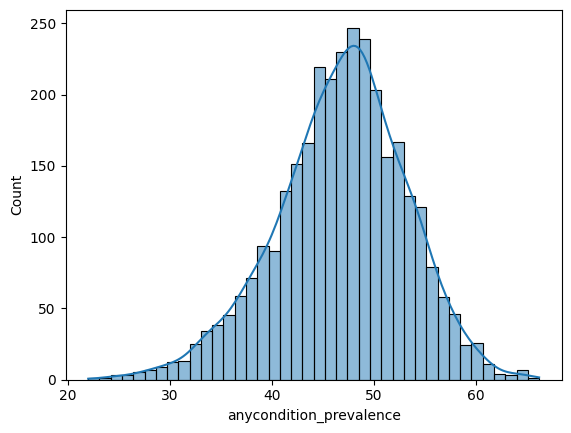

In [27]:
sns.histplot(total_data[target], kde=True)

**4. RELACIÓN CON VARIABLES IMPORTANTES**

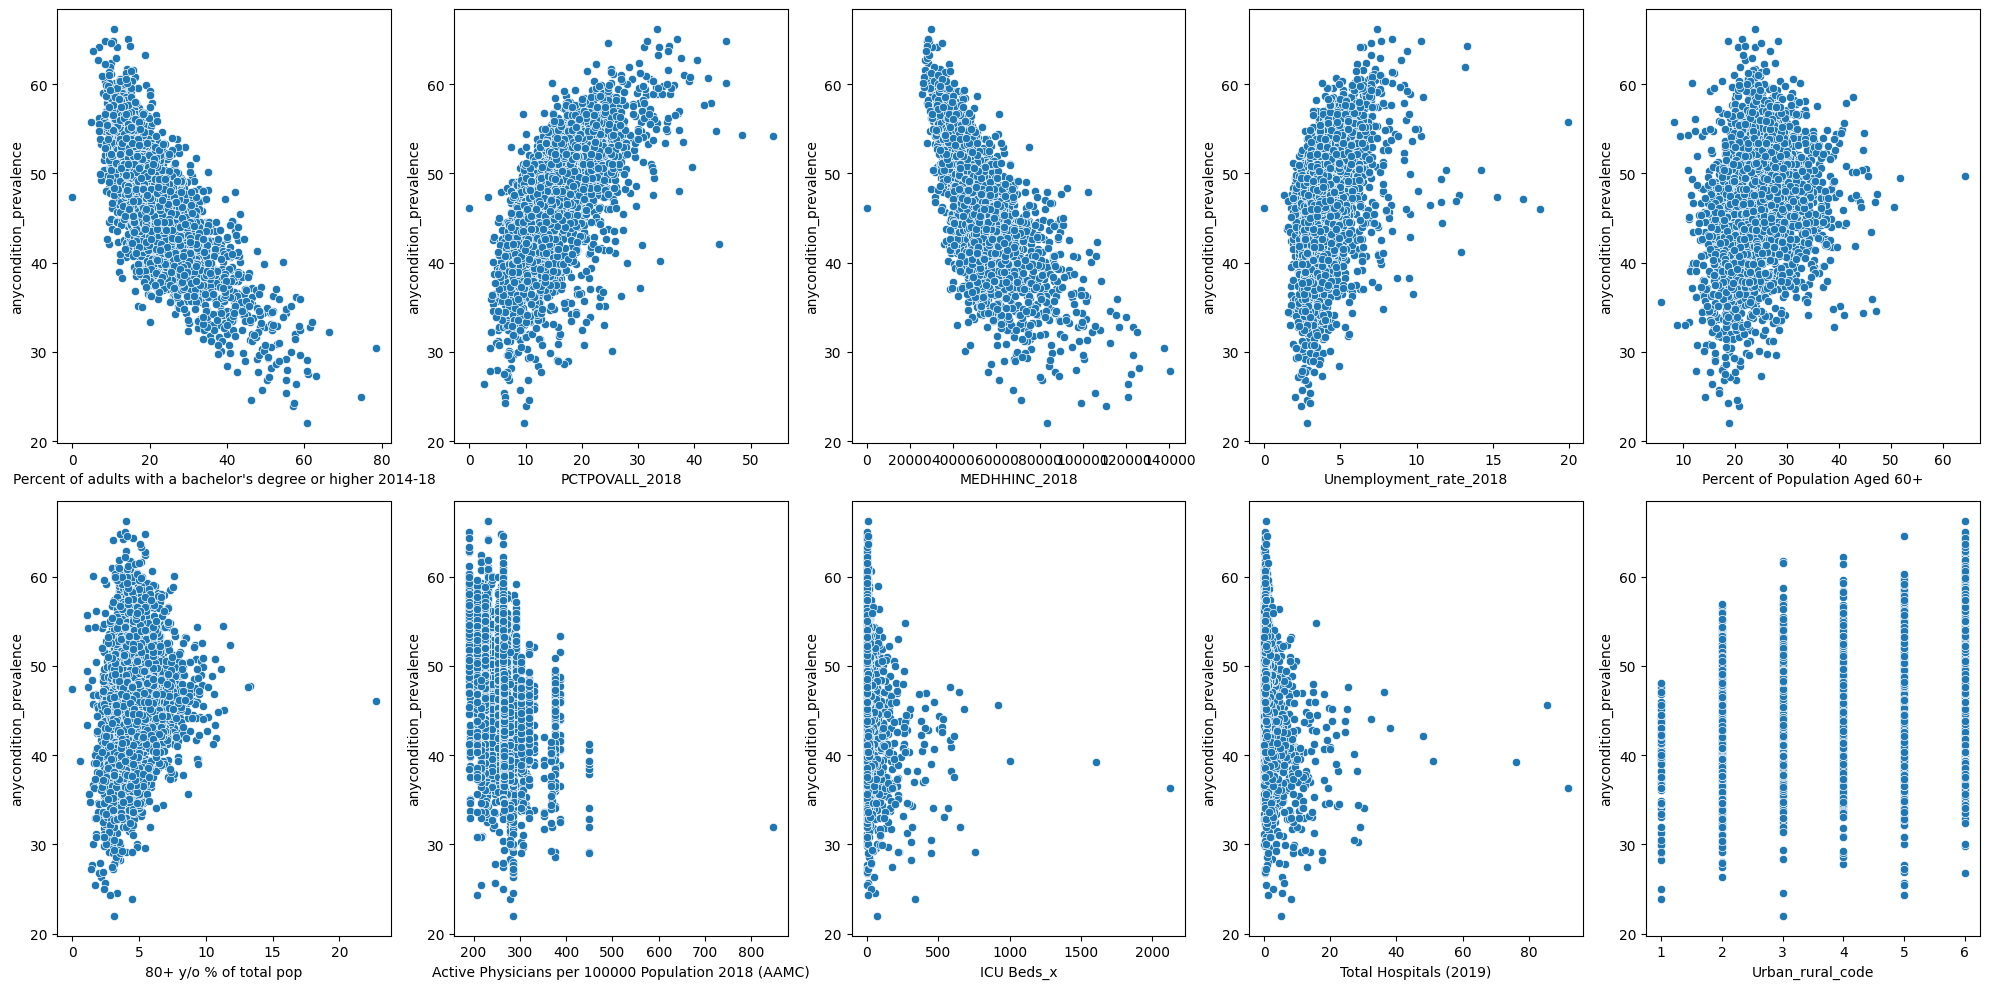

In [28]:
fig, axis = plt.subplots(2, 5, figsize=(20, 10))
axis = axis.flatten()
for i, col in enumerate(top_features):
    sns.scatterplot(data=total_data, x=col, y=target, ax=axis[i])
plt.tight_layout()
plt.show()

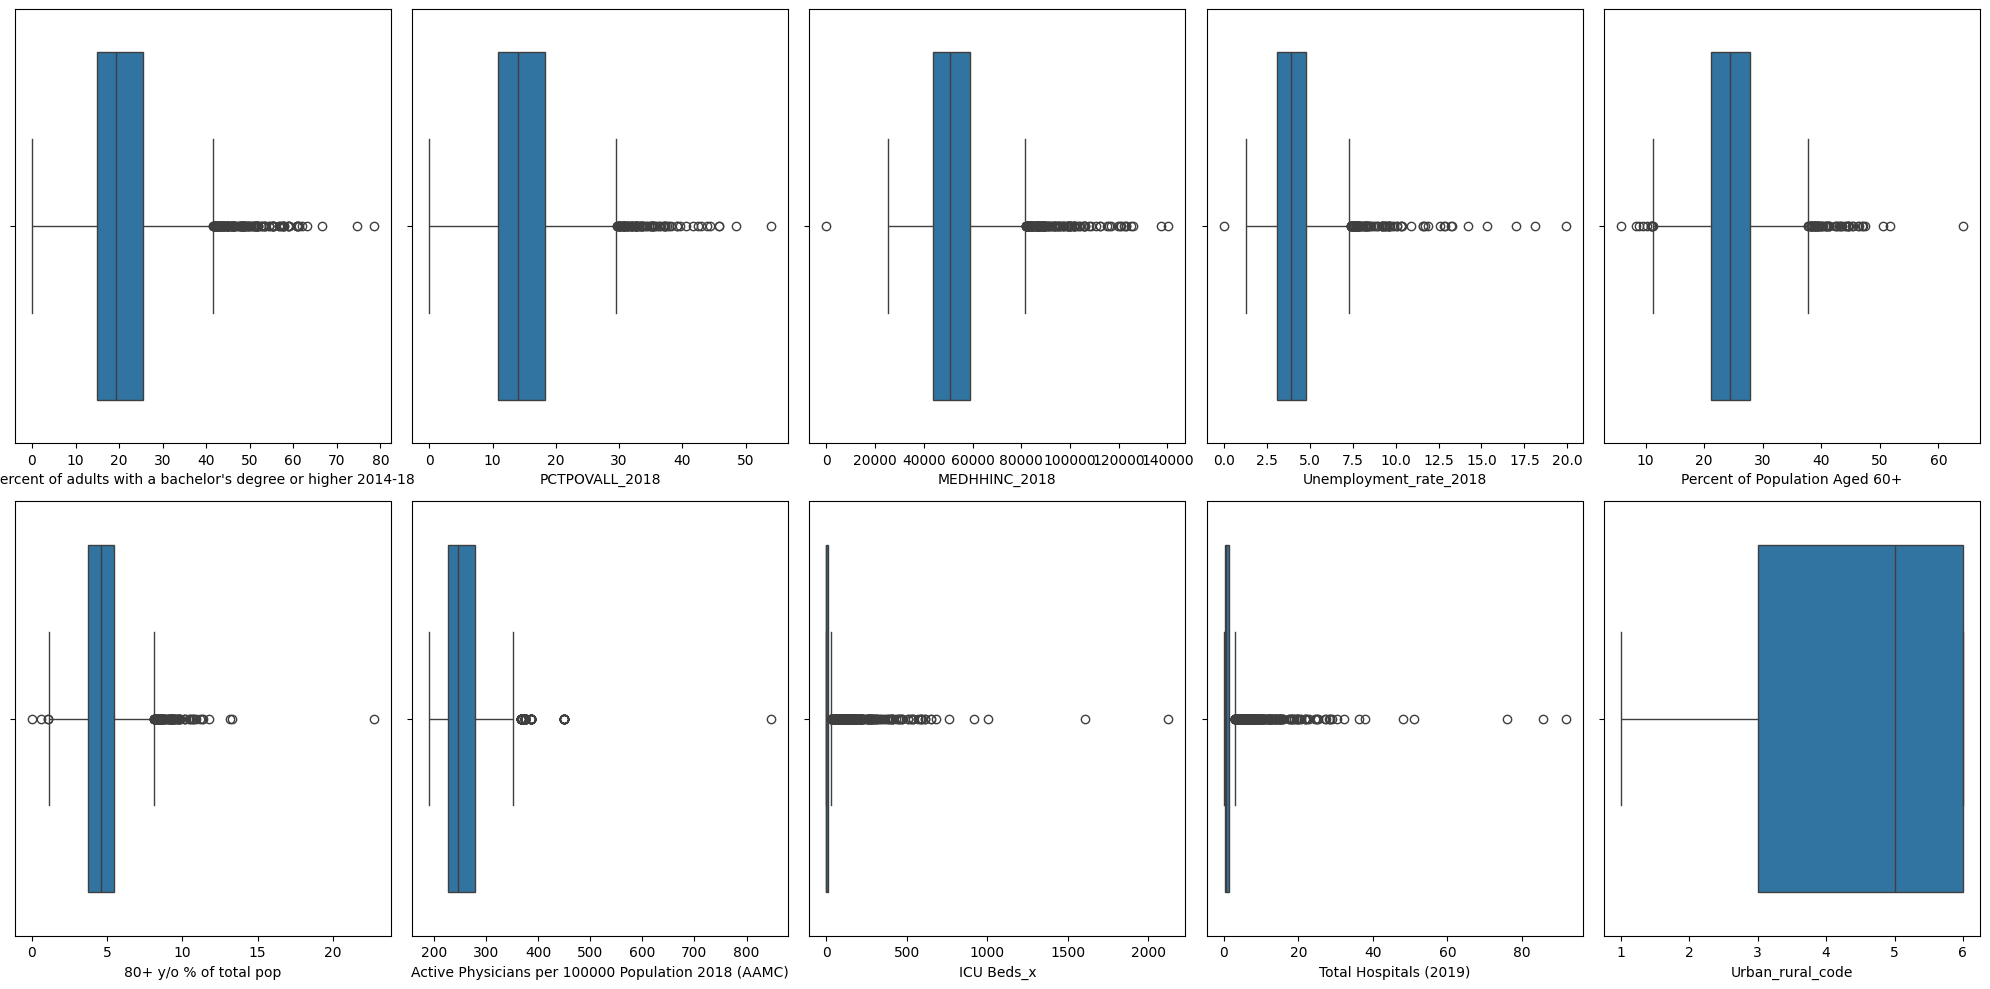

In [29]:
fig, axis = plt.subplots(2, 5, figsize=(20, 10))

sns.boxplot(ax = axis[0, 0], x = total_data["Percent of adults with a bachelor's degree or higher 2014-18"])
sns.boxplot(ax = axis[0, 1], x = total_data["PCTPOVALL_2018"])
sns.boxplot(ax = axis[0, 2], x = total_data["MEDHHINC_2018"])
sns.boxplot(ax = axis[0, 3], x = total_data["Unemployment_rate_2018"])
sns.boxplot(ax = axis[0, 4], x = total_data["Percent of Population Aged 60+"])

sns.boxplot(ax = axis[1, 0], x = total_data["80+ y/o % of total pop"])
sns.boxplot(ax = axis[1, 1], x = total_data["Active Physicians per 100000 Population 2018 (AAMC)"])
sns.boxplot(ax = axis[1, 2], x = total_data["ICU Beds_x"])
sns.boxplot(ax = axis[1, 3], x = total_data["Total Hospitals (2019)"])
sns.boxplot(ax = axis[1, 4], x = total_data["Urban_rural_code"])

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

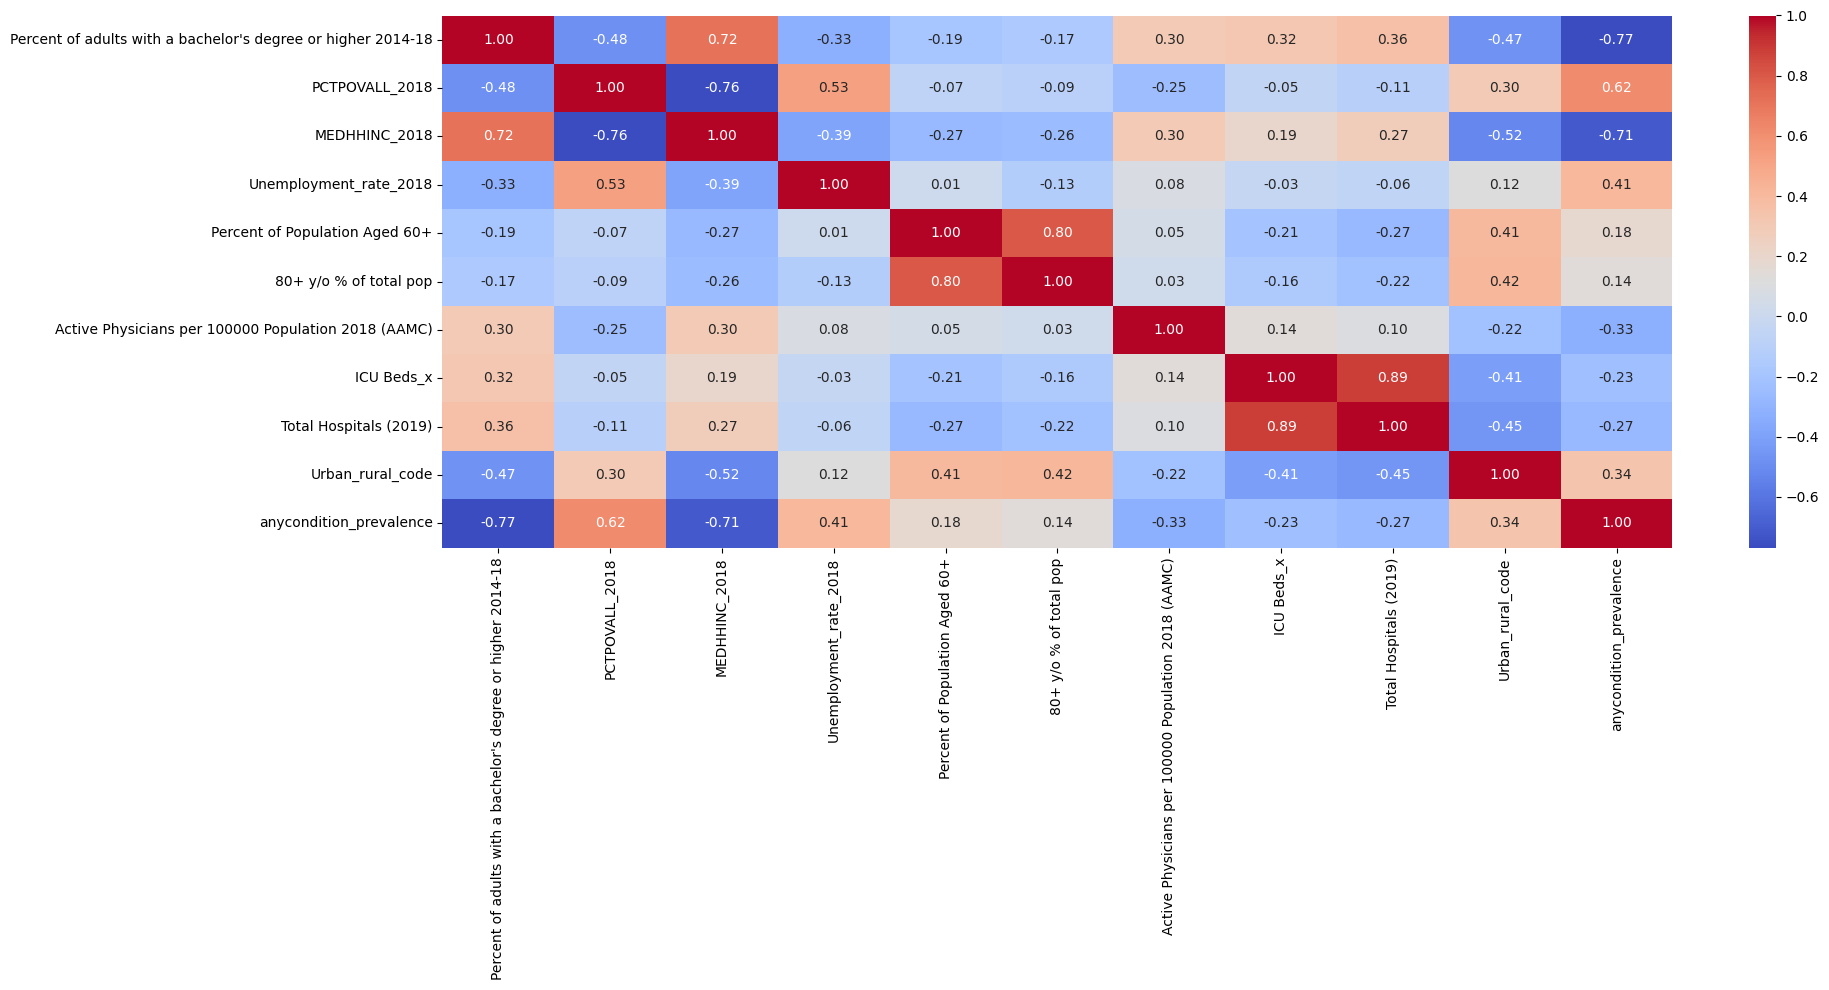

In [30]:
# Heatmap SOLO con variables relevantes
selected = list(top_features) + [target]

fig, ax= plt.subplots(figsize=(20, 10))
sns.heatmap(total_data[selected].corr(method="pearson"),
            annot=True, fmt=".2f", cmap="coolwarm", ax=ax)

plt.tight_layout()
plt.show

**5. INGENIERÍA DE CARACTERÍSTICAS**

In [31]:
total_data.describe()

,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,...,Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Population Aged 60+,Percent of Population Aged 60+,county_pop2018_18 and older,anycondition_prevalence,Urban_rural_code
count,3.140000e+03,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,...,3140.000000,3140.000000,3140.000000,3140.000000,3.140000e+03,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3140.000000
mean,1.041894e+05,1.274030e+04,11.871051,1.336798e+04,12.694609,1.446933e+04,12.283979,1.391649e+04,11.751535,1.288521e+04,...,62.898806,44.393892,167.332629,23.817516,1.022266e+05,2.132298e+04,24.736943,8.081460e+04,46.793917,4.635350
std,3.335834e+05,4.180730e+04,2.124081,4.228439e+04,1.815044,4.957773e+04,3.126297,4.899095e+04,1.696599,4.347219e+04,...,214.737693,133.348667,543.035916,84.602028,3.283878e+05,6.140588e+04,5.564871,2.585190e+05,6.379448,1.510447
min,8.800000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,1.100000e+01,6.092789,4.000000e+00,...,0.046773,0.030356,0.111759,0.000000,7.400000e+01,2.700000e+01,5.800000,8.800000e+01,22.000000,1.000000
25%,1.096325e+04,1.280500e+03,10.594639,1.374500e+03,11.674504,1.263750e+03,10.496774,1.232750e+03,10.689322,1.245250e+03,...,4.843825,5.312558,14.740077,0.000000,1.096700e+04,2.814750e+03,21.200000,8.460250e+03,42.900000,3.000000
50%,2.580050e+04,3.057000e+03,11.802727,3.274000e+03,12.687422,3.108000e+03,11.772649,3.000500e+03,11.580861,3.048500e+03,...,12.386405,12.153987,36.223582,0.000000,2.570400e+04,6.310000e+03,24.400000,2.023000e+04,47.200000,5.000000
75%,6.791300e+04,8.097000e+03,12.951840,8.822250e+03,13.659282,8.976250e+03,13.182260,8.314250e+03,12.639379,8.120500e+03,...,36.902489,31.312501,103.869345,12.000000,6.750075e+04,1.610625e+04,27.800000,5.282025e+04,51.000000,6.000000
max,1.010552e+07,1.208253e+06,25.460677,1.239139e+06,23.304372,1.557073e+06,37.570198,1.501844e+06,22.225129,1.350076e+06,...,5713.007608,3882.586846,15014.048660,2126.000000,1.010572e+07,1.800341e+06,64.200000,7.916625e+06,66.200000,6.000000


**Outliers para la variable objetivo ('anycondition_prevalence')**

In [32]:
# STATS TARGET
target_stats = total_data["anycondition_prevalence"].describe()
target_stats

count    3140.000000
mean       46.793917
std         6.379448
min        22.000000
25%        42.900000
50%        47.200000
75%        51.000000
max        66.200000
Name: anycondition_prevalence, dtype: float64

In [33]:
# IQR TARGET
# RANGO INTERCUARTIL
target_iqr = target_stats["75%"] - target_stats["25%"]
# LÍMITE SUPERIOR == Q3 + 1.5*IQR
upper_limit = target_stats["75%"] + 1.5 * target_iqr
# LÍMITE INFERIOR == Q1 + 1.5*IQR
lower_limit = target_stats["25%"] - 1.5 * target_iqr

print(f"IQR: {target_iqr}")
print(f"Upper limit: {upper_limit}")
print(f"Lower limit: {lower_limit}")

IQR: 8.100000000000001
Upper limit: 63.150000000000006
Lower limit: 30.749999999999996


In [34]:
total_data[total_data.anycondition_prevalence > 22]

,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,...,Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Population Aged 60+,Percent of Population Aged 60+,county_pop2018_18 and older,anycondition_prevalence,Urban_rural_code
0,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,...,25.992561,21.249061,72.142154,6,55036,10523,19.1,42438,47.6,3
1,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,...,101.921730,83.321572,282.882982,51,203360,53519,26.3,170912,40.2,4
2,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,...,11.631462,9.508784,32.283033,5,26201,6150,23.5,19689,57.5,6
3,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,3038,...,10.471635,8.560619,29.063942,0,22580,4773,21.1,17813,51.6,2
4,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,7474,...,27.039257,22.104740,75.047251,6,57667,13600,23.6,44448,46.3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,43051,6104,14.178532,6326,14.694200,5359,12.448027,6577,15.277229,5334,...,9.836192,28.018244,40.537033,10,44527,7015,15.8,31761,40.3,5
3136,23081,2384,10.328842,2185,9.466661,2967,12.854729,4093,17.733200,3423,...,5.273493,15.021465,21.733183,6,22923,4298,18.7,18842,24.3,5
3137,20299,3121,15.375142,3205,15.788955,2153,10.606434,2702,13.311001,2390,...,4.637868,13.210897,19.113638,6,20758,3554,17.1,14455,42.2,5
3138,7885,858,10.881420,1113,14.115409,715,9.067850,903,11.452124,900,...,1.801546,5.131678,7.424555,0,8253,2206,26.7,6092,37.5,6


**6. TRAIN / TEST SPLIT**

In [35]:
# SEPARO X E Y
mi_x = total_data.drop(target, axis=1)
mi_y = total_data[target]

In [36]:
# TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(mi_x, mi_y, test_size=0.2, random_state=42)

In [37]:
# FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [38]:
# LINEAR REGRESSION
model = LinearRegression()

In [39]:
# ENTRENO EL MODELO
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
model.intercept_

np.float64(13.477449297967738)

In [41]:
model.coef_

array([ 7.20029144e-05, -2.18237875e-04,  8.91981694e-02, -1.43520032e-04,
       -1.54494008e-01,  7.21943317e-05, -1.18518212e-01, -2.25621291e-05,
       -2.89461099e-01,  1.26829171e-04,  1.92299928e-01, -3.76837765e-05,
        2.49120798e-01,  2.41651507e-05, -1.19874981e-01,  1.44393249e-04,
       -8.41558500e-02,  1.26424813e-04,  2.35885269e-01,  3.31061108e-05,
       -1.82347368e-02,  3.12587267e-05,  1.71073638e-02, -3.62990295e-05,
        2.66476651e-03,  3.90186731e-05, -1.74286147e-01, -4.13867477e-05,
       -7.96678192e-03,  4.63051129e-05,  1.80715533e-01,  7.20029064e-05,
        4.48333134e-05,  5.46015079e-05,  8.63366076e-02,  3.77323011e-01,
        2.72923341e-02, -1.13003830e+00, -1.10555152e+00,  1.09322558e+00,
        5.26502349e-05,  6.59087693e-05,  9.45497632e-05,  6.15909142e-05,
        4.81586062e-01,  3.88957773e-01,  3.41352393e-01,  1.61857729e-01,
       -1.28634622e-05,  1.37204561e-01,  1.69696403e-01, -1.42891156e-01,
       -3.71582485e-05, -

In [42]:
# PREDICCIONES
y_pred = model.predict(X_test)

In [43]:
# MSE
mean_squared_error(y_test, y_pred)

7.995792862743568

- El Error Cuadrático Medio (MSE) de 7.99 indica que, en promedio, las predicciones se desvían del valor real alrededor de 2.82 unidades.

In [44]:
# R²
r2_score(y_test, y_pred)

0.8033231068864799

- El modelo explica aproximadamente el 80% de la variabilidad de la variable objetivo del dataset ('anycondition_prevalence').

In [45]:
# MODELO LASSO
lasso_model = Lasso(alpha=0.1, max_iter=300, random_state=42)

# ENTRENO EL MODELO
lasso_model.fit(X_train_scaled, y_train)

# PREDICCIONES
y_pred_lasso = lasso_model.predict(X_test)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


In [46]:
# Probar distintos alpha
alphas = np.linspace(0, 20, 50)
scores = []

for a in alphas:
    model = Lasso(alpha=a)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(r2_score(y_test, y_pred))

/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.886e+03, tolerance: 1.022e+01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_co

Text(0.5, 1.0, 'Lasso performance')

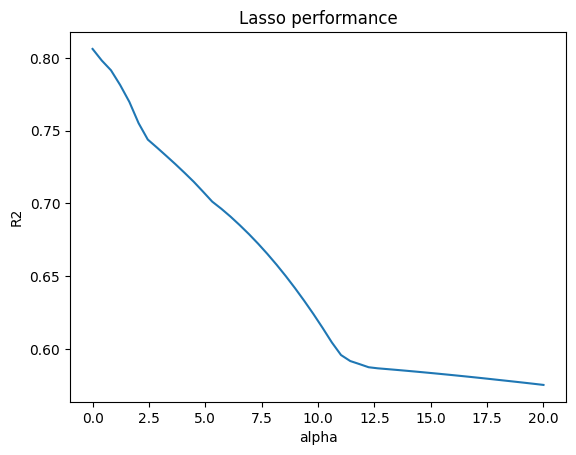

In [47]:
# GRAFICAR RESULTADOS
plt.plot(alphas, scores)
plt.xlabel("alpha")
plt.ylabel("R2")
plt.title("Lasso performance")

**7. OPTIMIZACIÓN DEL MODELO**

In [48]:
# MODELO RIDGE
ridge_model = Ridge(alpha=0.1, max_iter=300, random_state=42)

# ENTRENO EL MODELO RIDGE
ridge_model.fit(X_train, y_train)

# PREDICCIONES
y_pred_ridge = ridge_model.predict(X_test)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.0645858833448545e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


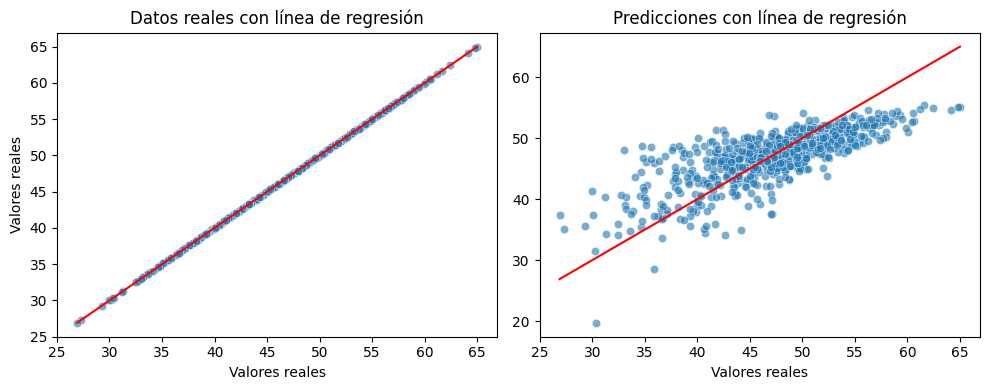

In [49]:
# COMPARO EL VALOR PREDICHO VS EL VALOR REAL
fig, axis = plt.subplots(1, 2, figsize=(10, 4))

# DATOS REALES
sns.scatterplot(ax=axis[0], x=y_test, y=y_test, alpha=0.6)
sns.lineplot(ax=axis[0], x=[y_test.min(), y_test.max()], 
             y=[y_test.min(), y_test.max()], color='red')
axis[0].set_title("Datos reales con línea de regresión")
axis[0].set_xlabel("Valores reales")
axis[0].set_ylabel("Valores reales")

# PREDICCIONES
sns.scatterplot(ax=axis[1], x=y_test, y=y_pred, alpha=0.6)
sns.lineplot(ax=axis[1], x=[y_test.min(), y_test.max()], 
             y=[y_test.min(), y_test.max()], color='red')
axis[1].set_title("Predicciones con línea de regresión")
axis[1].set_xlabel("Valores reales")
axis[1].set_ylabel(None)

plt.tight_layout()
plt.show()

**8. CONCLUSIONES**

- El dataset inicial contenía 3140 filas y 108 columnas relacionadas con datos sociodemográficos a nivel de condado de EE. UU. (2018-2019).
- Incluye variables relacionnadas con la salud de las personas.
- El objetivo es descubrir si existe alguna relación entre los recursos de salud y los datos sociodemográficos.

**Análisis de variables**
- Se eliminaron las variables 'COUNTY_NAME' y 'STATE_NAME' porque no aportan valor predictivo al modelo. Además, al ser las únicas variables categóricas, no se pueden utilizar directamente en una regresión lineal sin transformarlas previamente.
- Se eliminaron las variables 'anycondition_Lower 95% CI','anycondition_Upper 95% CI' y 'anycondition_number' porque son derivados directos de la variable objetivo y dejarlas podría causar data leakage.
- Se eliminaron las variables 'fips', 'STATE_FIPS', 'CNTY_FIPS' porque son identificadores; no aportan valor.
- Debido al alto número de variables numéricas (100), se seleccionaron aquellas con mayor correlación con la variable objetivo para facilitar la interpretación.
- Se seleccionó 'anycondition_prevalence' como variable objetivo, ya que representa el porcentaje de población con alguna condición médica, siendo un indicador global del estado de salud. Esto permite analizar cómo los factores sociodemográficos y los recursos sanitarios influyen en la salud de la población.

**Matriz de correlación**


**Conclusiones del proyecto**
- El modelo explica aproximadamente el 80% de la variabilidad de la variable objetivo del dataset ('anycondition_prevalence').
- El Error Cuadrático Medio (MSE) de 7.99 indica que, en promedio, las predicciones se desvían del valor real alrededor de 2.82 unidades.